# Sentiment Analysis

This notebook demonstrates loading the legal notices dataset, preprocessing text, extracting features, and preparing for model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/legal_notices.csv")
df.head(10)

,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...


# Part 1.1 Problem Framing


## Machine Learning Task Type

This is a multi-class classification problem because the model must classify legal notices into one of three categories:

- Contract Dispute
- Intellectual Property Claim
- Regulatory Compliance

The target variable contains predefined class labels, therefore classification is the most suitable machine learning task.

## Assumptions

1. The class labels in the dataset are correct and accurately represent the notice category.
2. The text contains enough information to distinguish between the three legal categories.
3. Future legal notices will have a similar writing style and vocabulary as the training data.

## Constraints

1. Interpretability is important because legal professionals may want to understand model decisions.
2. Fast inference is required because the company processes thousands of notices.
3. The dataset size is relatively small (200 samples), which may limit model performance.

## Primary Evaluation Metric

The primary evaluation metric is Macro F1-Score.

Reason:
Macro F1 treats all classes equally and balances precision and recall. It is suitable for multi-class classification, especially when class distributions may not be perfectly balanced.


# Part 1.2 Approach Comparison

## Approach 1: Logistic Regression + TF-IDF

Description:
A linear classification model trained on TF-IDF text features.

Strengths:
- Works well on text classification tasks.
- Fast training and prediction.
- Easy to interpret.

Weaknesses:
- May not capture complex relationships.
- Performance depends on feature quality.

## Approach 2: Multinomial Naive Bayes + Bag of Words

Description:
A probabilistic classifier commonly used for text classification.

Strengths:
- Very fast.
- Performs well on small datasets.
- Works effectively with word frequency features.

Weaknesses:
- Assumes feature independence.
- Can miss relationships between words.

## Final Selection

Both models will be implemented and evaluated.

The final recommendation will be based on empirical performance using Accuracy, Precision, Recall and F1-score.

# Part 2.1 Exploratory Data Analysis (EDA)

In [3]:
print(df.columns)
print(df.head())

Index(['id', 'category', 'label', 'notice'], dtype='object')
   id category                        label  \
0   1        C        Regulatory Compliance   
1   2        A             Contract Dispute   
2   3        B  Intellectual Property Claim   
3   4        A             Contract Dispute   
4   5        C        Regulatory Compliance   

                                              notice  
0  FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...  
1  NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...  
2  NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...  
3  BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...  
4  TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...  


In [4]:
# First 10 rows

df.head(10)

,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...


In [5]:
# Total samples

print("Total Samples:", len(df))

Total Samples: 600


In [6]:
# Class Distribution

print(df['label'].value_counts())

label
Regulatory Compliance          200
Contract Dispute               200
Intellectual Property Claim    200
Name: count, dtype: int64


In [7]:
# Missing Values

print(df.isnull().sum())

id          0
category    0
label       0
notice      0
dtype: int64


In [8]:
# Average Notice Length

df['notice_length'] = df['notice'].apply(len)

print("Average Notice Length:",
      df['notice_length'].mean())

Average Notice Length: 792.08


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             600 non-null    int64 
 1   category       600 non-null    object
 2   label          600 non-null    object
 3   notice         600 non-null    object
 4   notice_length  600 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 23.6+ KB


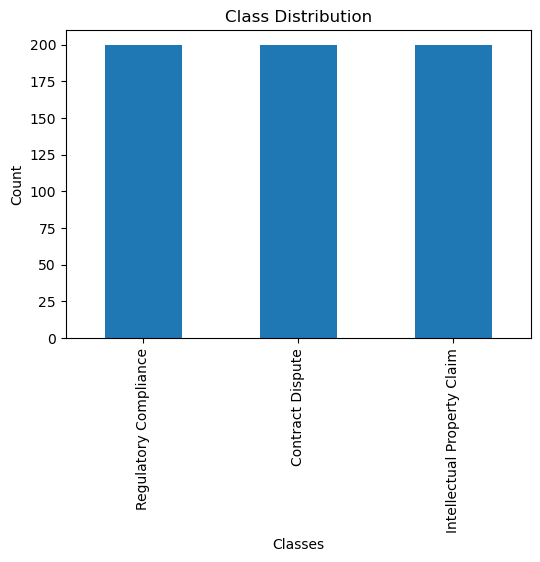

In [10]:
plt.figure(figsize=(6,4))

df['label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.show()

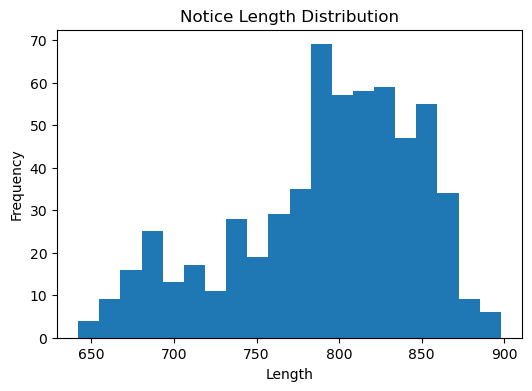

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df['notice_length'], bins=20)

plt.title("Notice Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## Data Quality Issue

Some legal notices contain uppercase text, special characters and legal formatting patterns which may introduce noise during feature extraction.

Therefore preprocessing is required before model training.

In [12]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [14]:
def preprocess_text(text):
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = text.split()
    
    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]
    
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

In [15]:
df['clean_notice'] = df['notice'].apply(preprocess_text)

df[['notice','clean_notice']].head()

,notice,clean_notice
0,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...,financi report noncompli notic global payment ...
1,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...,notic contract termin caus coastal logist part...
2,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...,notic patent licens oblig synthlab solut quant...
3,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...,breach confidenti notic horizon enterpris grou...
4,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...,telecommun licenc complianc notic pinnacl lend...


## Preprocessing Justification

1. HTML tags removed to eliminate unnecessary markup.
2. Lowercasing applied to ensure consistency.
3. Punctuation and special characters removed to reduce noise.
4. Tokenization performed to split text into words.
5. Stopwords removed because they carry little semantic meaning.
6. Porter Stemming applied to reduce words to their root forms and decrease feature dimensionality.